In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Imports**

In [2]:
import sys
import os

import torch
from transformers import AutoTokenizer,AutoModelForSequenceClassification,AutoModel
from peft import PeftConfig,PeftModel

from sentence_transformers import SentenceTransformer
import numpy as np

**Loading Model & Tokenizer**

In [3]:
LABELS=["Syntax Error", "Runtime Error", "Logic Bug", "Multiple Issues"]
save_path = "/content/drive/MyDrive/code-debugger/ml_service/model/lora_weights"
config=PeftConfig.from_pretrained(save_path)
base=AutoModelForSequenceClassification.from_pretrained(
    config.base_model_name_or_path,num_labels=len(LABELS)
)
model=PeftModel.from_pretrained(base,save_path)
model.eval()
tokenizer=AutoTokenizer.from_pretrained(save_path)
print("model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model loaded


**Classification Func**

In [4]:
def classify(code: str) -> dict:
    inputs = tokenizer(
        code, return_tensors="pt",
        truncation=True, max_length=256
    )
    with torch.no_grad():
        logits = model(**inputs).logits

    probs = torch.softmax(logits, dim=-1).squeeze().tolist()
    pred_idx = torch.argmax(logits).item()

    return {
        "label": LABELS[pred_idx],
        "confidence": round(probs[pred_idx], 3),
        "all_scores": {LABELS[i]: round(p, 3) for i, p in enumerate(probs)}
    }



In [5]:
result = classify("def greet(name)\n    print('hi')")
print(f"Label:      {result['label']}")
print(f"Confidence: {result['confidence']*100:.1f}%")
print(f"All scores: {result['all_scores']}")


Label:      Syntax Error
Confidence: 85.8%
All scores: {'Syntax Error': 0.858, 'Runtime Error': 0.14, 'Logic Bug': 0.0, 'Multiple Issues': 0.001}


**Semantic similarity**

In [6]:
embed_model=SentenceTransformer("BAAI/bge-small-en-v1.5")
index=[]

def add_to_index(code:str,fix:str,explanation:str):
  emb=embed_model.encode(code,normalize_embeddings=True)
  index.append({"code":code,"fix":fix,"explanation":explanation,"embedding":emb})

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
def search_similar(query_code: str, top_k: int = 3) -> list:
    if not index:
        return []
    q_emb = embed_model.encode(query_code, normalize_embeddings=True)
    scores = [float(np.dot(q_emb, item["embedding"])) for item in index]
    ranked = sorted(zip(scores, index), key=lambda x: x[0], reverse=True)
    return [
        {"score": round(s, 3), "code": item["code"], "explanation": item["explanation"]}
        for s, item in ranked[:top_k]
    ]

In [8]:
add_to_index(
    "def greet(name)\n    print('hi')",
    "def greet(name):\n    print('hi')",
    "Missing colon after function definition"
)
add_to_index(
    "x = [1,2,3]\nprint(x[10])",
    "x = [1,2,3]\nprint(x[2])",
    "Index 10 is out of range for a list of length 3"
)
add_to_index(
    "def is_even(n):\n    return n % 2 == 1",
    "def is_even(n):\n    return n % 2 == 0",
    "Wrong condition: should return True when remainder is 0 not 1"
)

In [9]:
results = search_similar("def foo(name)\n    print(name)")
print("\nSimilar bugs found:\n")
for r in results:
    print(f"  Score: {r['score']}  |  {r['explanation']}")


Similar bugs found:

  Score: 0.741  |  Missing colon after function definition
  Score: 0.691  |  Index 10 is out of range for a list of length 3
  Score: 0.582  |  Wrong condition: should return True when remainder is 0 not 1


**Attention Visualization**

In [10]:
attn_model=AutoModel.from_pretrained(
    "distilbert-base-uncased",
    output_attentions=True
)
attn_model.eval()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [15]:
def get_attention(code:str) -> dict:
  inputs=tokenizer(
      code, return_tensors="pt",
      truncation=True,max_lenght=64
  )
  tokens=tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())
  with torch.no_grad():
    outputs=attn_model(**inputs)
  attn=outputs.attentions[-1][0]
  avg_attn=attn.mean(dim=0).tolist()
  return {
        "tokens": tokens,
        "matrix": avg_attn,
        "num_layers": len(outputs.attentions),
        "num_heads": int(attn.shape[0]),
    }




In [16]:
result = get_attention("def greet(name)\n    print('hi')")
print(f" Tokens: {result['tokens']}")
print(f" Layers: {result['num_layers']}  |  Heads: {result['num_heads']}")
print(f" Matrix shape: {len(result['matrix'])} x {len(result['matrix'][0])}")

 Tokens: ['[CLS]', 'def', 'greet', '(', 'name', ')', 'print', '(', "'", 'hi', "'", ')', '[SEP]']
 Layers: 6  |  Heads: 12
 Matrix shape: 13 x 13


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention(code: str):
    result = get_attention(code)
    tokens = result["tokens"]
    matrix = np.array(result["matrix"])

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(matrix, cmap="Blues")

    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(tokens, fontsize=9)

    plt.colorbar(im, ax=ax)
    ax.set_title("DistilBERT attention weights — last layer avg across 12 heads")
    plt.tight_layout()
    plt.show()

    print(f" Attention heatmap plotted for {len(tokens)} tokens")



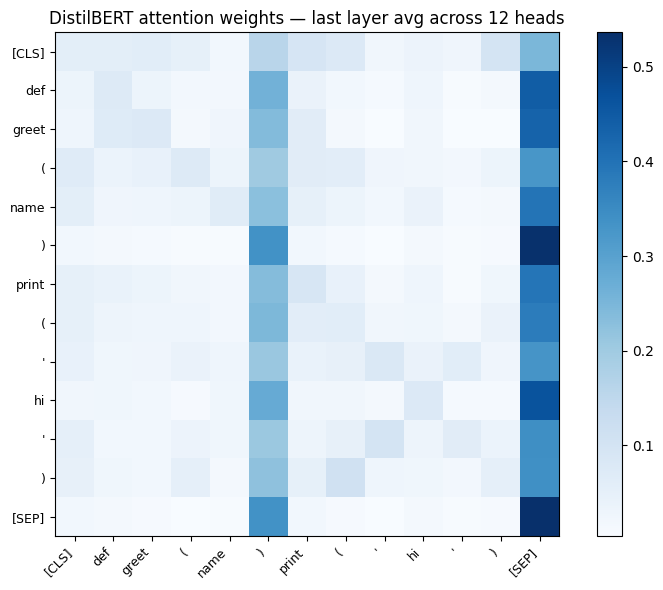

 Attention heatmap plotted for 13 tokens


In [18]:
plot_attention("def greet(name)\n    print('hi')")

In [19]:
%%writefile /content/drive/MyDrive/code-debugger/ml_service/model/inference.py
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
from peft import PeftModel, PeftConfig
from sentence_transformers import SentenceTransformer

LABELS = ["Syntax Error", "Runtime Error", "Logic Bug", "Multiple Issues"]
SAVE_PATH = "/content/drive/MyDrive/code-debugger/ml_service/model/lora_weights"

# ── Load classifier ───────────────────────────────────────────────────────────
config = PeftConfig.from_pretrained(SAVE_PATH)
base = AutoModelForSequenceClassification.from_pretrained(
    config.base_model_name_or_path, num_labels=len(LABELS)
)
model = PeftModel.from_pretrained(base, SAVE_PATH)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)

# ── Load embedding model ──────────────────────────────────────────────────────
embed_model = SentenceTransformer("BAAI/bge-small-en-v1.5")
index = []

# ── Load attention model ──────────────────────────────────────────────────────
attn_model = AutoModel.from_pretrained(
    "distilbert-base-uncased", output_attentions=True
)
attn_model.eval()


def classify(code: str) -> dict:
    inputs = tokenizer(code, return_tensors="pt", truncation=True, max_length=256)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze().tolist()
    pred_idx = torch.argmax(logits).item()
    return {
        "label": LABELS[pred_idx],
        "confidence": round(probs[pred_idx], 3),
        "all_scores": {LABELS[i]: round(p, 3) for i, p in enumerate(probs)},
    }


def add_to_index(code: str, fix: str, explanation: str):
    emb = embed_model.encode(code, normalize_embeddings=True)
    index.append({"code": code, "fix": fix, "explanation": explanation, "emb": emb})


def search_similar(query_code: str, top_k: int = 3) -> list:
    if not index:
        return []
    q_emb = embed_model.encode(query_code, normalize_embeddings=True)
    scores = [float(np.dot(q_emb, item["emb"])) for item in index]
    ranked = sorted(zip(scores, index), key=lambda x: x[0], reverse=True)
    return [
        {"score": round(s, 3), "code": item["code"], "explanation": item["explanation"]}
        for s, item in ranked[:top_k]
    ]


def get_attention(code: str) -> dict:
    inputs = tokenizer(code, return_tensors="pt", truncation=True, max_length=64)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())
    with torch.no_grad():
        outputs = attn_model(**inputs)
    last_layer = outputs.attentions[-1][0]
    avg_attn = last_layer.mean(dim=0).tolist()
    return {
        "tokens": tokens,
        "matrix": avg_attn,
        "num_layers": len(outputs.attentions),
        "num_heads": int(last_layer.shape[0]),
    }

Writing /content/drive/MyDrive/code-debugger/ml_service/model/inference.py
